The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


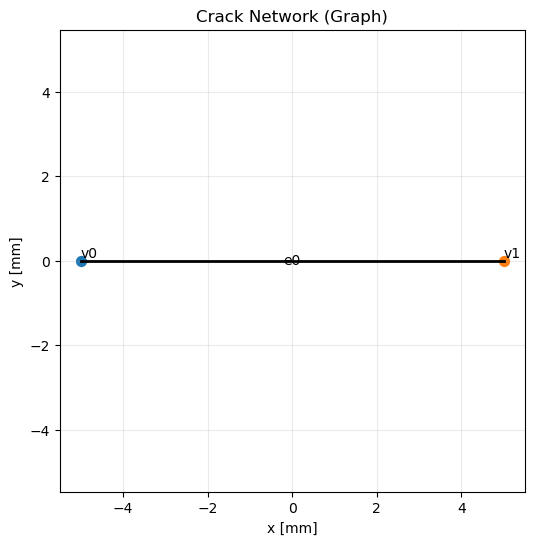

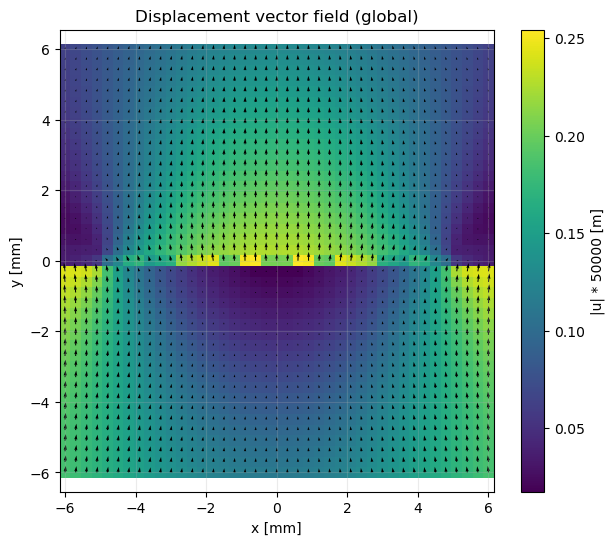

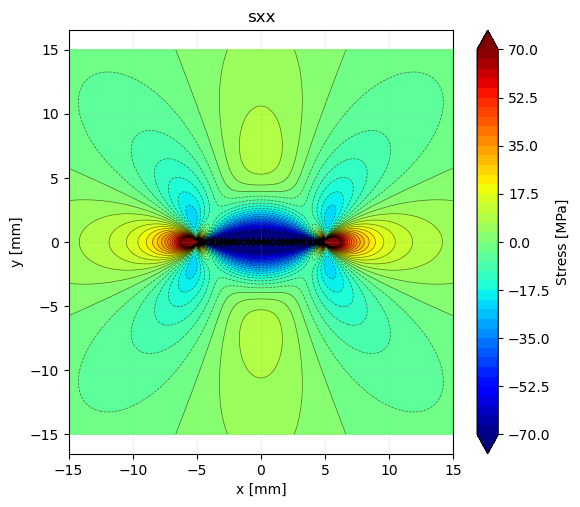

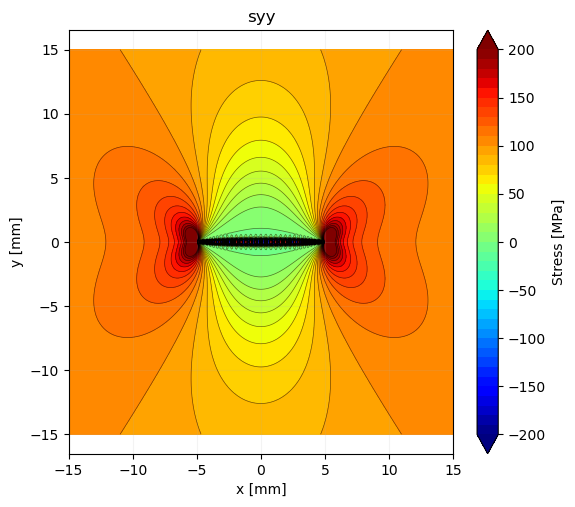

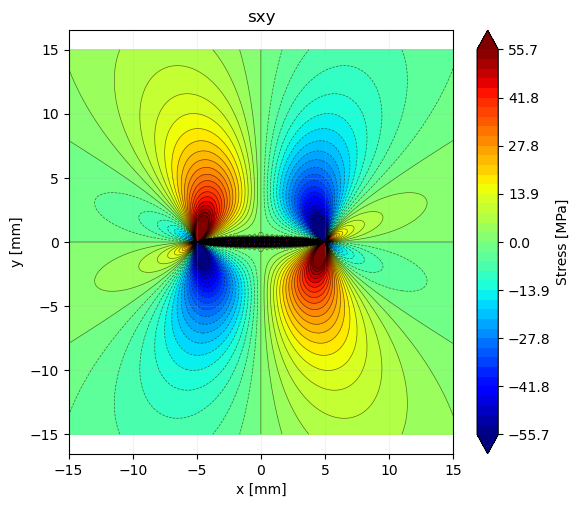

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1


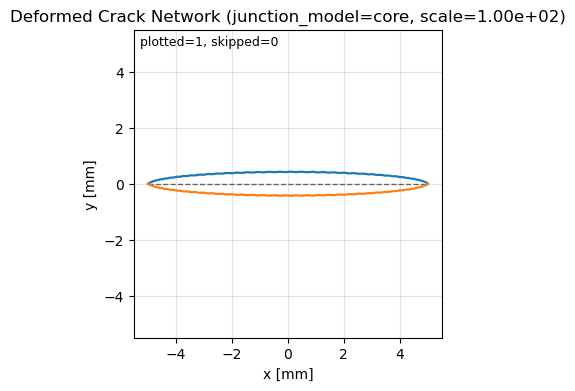

(<Figure size 650x400 with 1 Axes>,
 <Axes: title={'center': 'Deformed Crack Network (junction_model=core, scale=1.00e+02)'}, xlabel='x [mm]', ylabel='y [mm]'>)

In [4]:
import numpy as np
from pathlib import Path
import os, sys, importlib
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)
    
from preamble import *
enable_autoreload()
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1")
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Define Y network: vertices + connectivity
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   -5.0*mm,  0.0*mm],   
    [1,   5.0*mm,  0*mm], 
], dtype=float)

# edges: (edge_id, v0, v1)
connectivity = np.array([
    [0, 1],
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=40,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
    enforce_cod_nonnegative=True,
    cod_tol=1e-10,
    cod_max_iter=25,
)


res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=False,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=False,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)


# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
pl_def.plot_deformed_network(
    n_pts_per_edge=200,
    scale=1e2,
    show_faces=True,
    units="mm",
    cod_smooth_window=5,
    csd_smooth_window=5,
    junction_model="core",
)

Using repo_root = C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3
fracture_utils importable = True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Output directory exists: True
Output directory: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\COD_validation


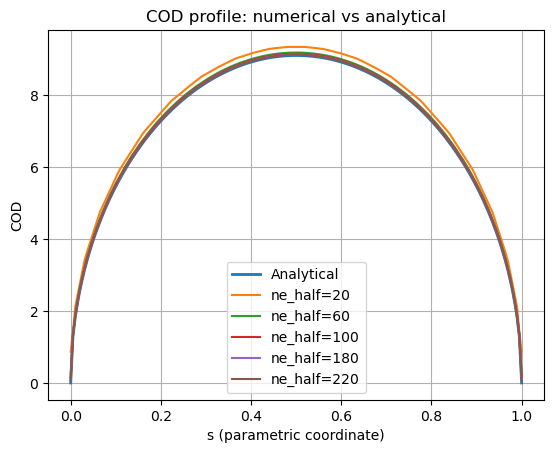

Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\COD_validation\cod_overlay_ne_half.png


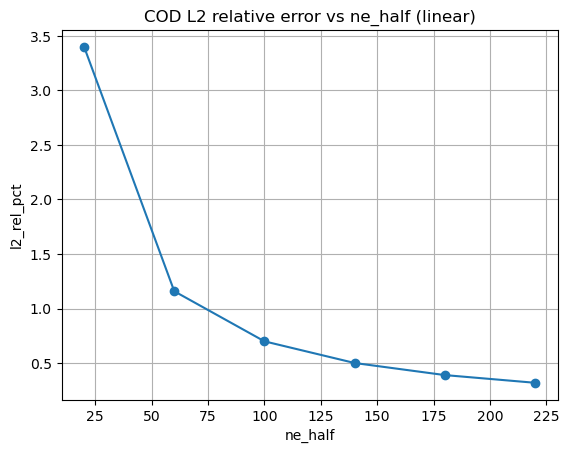

Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\COD_validation\cod_l2_error_vs_ne_half_linear.png


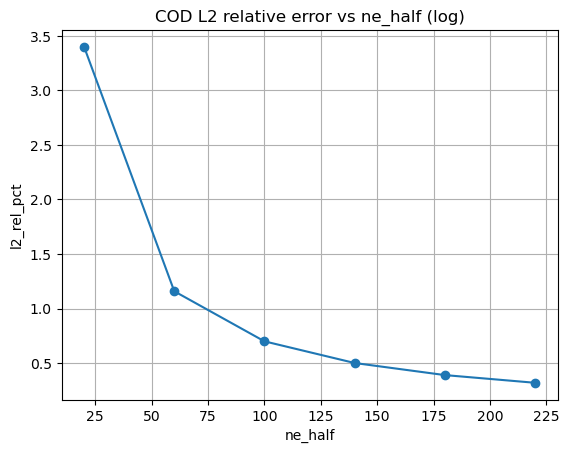

Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\COD_validation\cod_l2_error_vs_ne_half_log.png


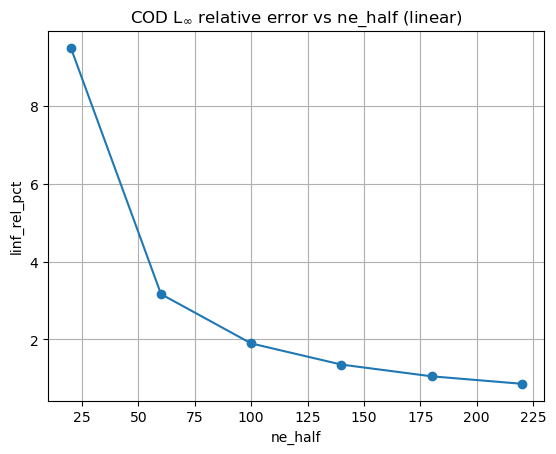

Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\COD_validation\cod_linf_error_vs_ne_half_linear.png


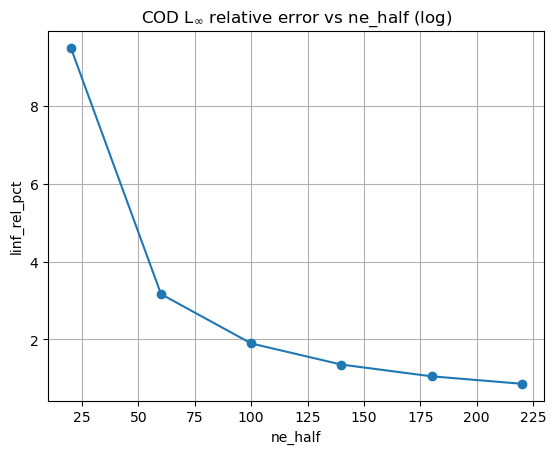

Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\COD_validation\cod_linf_error_vs_ne_half_log.png

All plots saved to: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\COD_validation


In [25]:
# --- COD Validation Cell (fixed calc/network wiring) ---
import os, sys
from pathlib import Path

cwd = Path(os.getcwd()).resolve()

# Find the nearest parent that contains a "fracture_utils" folder
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "fracture_utils").is_dir():
        repo_root = p
        break

if repo_root is None:
    # Fallback: hardcode the path you already see in tracebacks
    repo_root = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo_root =", repo_root)
print("fracture_utils importable =", (repo_root / "fracture_utils").is_dir())

from fracture_utils.UValidation.validation_cod import (
    CODProfile,
    run_cod_sweep,
    plot_cod_overlay,
    plot_cod_error_vs_knob,
)

from preamble import *
enable_autoreload()

# -------------------------
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\COD_validation")
out_dir.mkdir(parents=True, exist_ok=True)

# Verify directory was created
print(f"Output directory exists: {out_dir.exists()}")
print(f"Output directory: {out_dir}")

# -------------------------
# Crack/physics metadata (benchmark)
# IMPORTANT: keep 'a' consistent with the geometric half-length used below.
# -------------------------
mm = 1e-3
a_geom = 5.0 * mm  # half-length (meters)

crack_meta = dict(
    a=a_geom,
    sigma=100e6,       # magnitude used in analytical COD (Pa)
    E=200e9,
    nu=0.30,
    plane="strain",    # "strain" or "stress"
    edge_index=0,
)

# -------------------------
# Define a single straight crack network (one edge)
# Use a HORIZONTAL crack for Mode I under sigma_yy tension.
# -------------------------
vertices = np.array([
    [0, -a_geom, 0.0],   # [id, x, y]
    [1, +a_geom, 0.0],
], dtype=float)

connectivity = np.array([
    [0, 1],              # edge from v0 -> v1
], dtype=int)

network = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=crack_meta["E"], nu=crack_meta["nu"], plane_stress=("stress" in crack_meta["plane"].lower()))

# Remote loading: uniform tension in y gives Mode I for a horizontal crack
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=+crack_meta["sigma"], sigma_xy=0.0)

# IMPORTANT:
#   - "network" is the geometry
#   - "calc" is the solver object that HAS calc.network, calc.material, calc.applied
calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

# -------------------------
# COD solver hook for validation_cod.run_cod_sweep
# -------------------------
def run_solver_cod(knobs, crack_meta):
    """
    Return CODProfile(s, COD) for one edge using panel-midpoint reconstruction.
    COD is stored in MICRONS for plotting convenience.
    """
    sol = calc.solve(**knobs)

    # DCEResultsNetworkV4 expects (calc, sol), not (network, sol)
    res = DCEResultsNetworkV4(calc, sol)

    edge_index = int(crack_meta.get("edge_index", 0))
    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    x = np.asarray(x, float).reshape(-1)
    COD = np.asarray(COD, float).reshape(-1) * 1e6  # Convert meters to microns
    CSD = np.asarray(CSD, float).reshape(-1)
    extra = dict(extra) if isinstance(extra, dict) else {}

    a_edge = float(extra.get("a_edge", np.max(np.abs(x))))
    s = (x + a_edge) / (2.0 * a_edge)  # map x in [-a_edge, a_edge] -> s in [0,1]

    return CODProfile(
        s=s,
        cod=COD,  # Now in microns
        meta=dict(x=x, CSD=CSD, **extra),
    )

# -------------------------
# Analytical COD: infinite plate, straight central crack under uniform tension
# delta(x) = (4*sigma/E')*sqrt(a^2 - x^2)
# Returns COD in MICRONS
# -------------------------
def analytical_cod(s, crack_meta):
    a = float(crack_meta["a"])
    sigma = float(crack_meta["sigma"])
    E = float(crack_meta["E"])
    nu = float(crack_meta["nu"])
    plane = str(crack_meta.get("plane", "strain")).lower()
    Eprime = E / (1.0 - nu**2) if "strain" in plane else E

    s = np.asarray(s, float)
    x = (2.0 * s - 1.0) * a
    cod_m = (4.0 * sigma / Eprime) * np.sqrt(np.maximum(a * a - x * x, 0.0))
    return cod_m * 1e6  # Convert meters to microns

# -------------------------
# Knob sweep
# -------------------------
ne_half_list = list(range(20, 260, 40))

knob_sweep = []
for ne in ne_half_list:
    knob_sweep.append(dict(
        ne_half=ne,
        crack_mode="full",
        representation="cheb_quad",   # or "panel", "singular", "cheb_quad"
        node_distribution="tip_dense",
        nq_col=12,
        nq_stress=16,
        ridge=1e-10,
        r0_factor=1e-3,
        solver_option="parametrized_crack",
        parametrization="polyline",
    ))

# -------------------------
# Run COD sweep
# -------------------------
sweep = run_cod_sweep(
    crack_meta=crack_meta,
    knob_sweep=knob_sweep,
    run_solver=run_solver_cod,
    analytical_cod=analytical_cod,
    s_sample=201,
)

# -------------------------
# Plot and save all figures
# -------------------------

# Figure 1: COD overlay
result1 = plot_cod_overlay(
    sweep,
    knob_label_keys=("ne_half",),
    max_curves=5,
    title="COD profile: numerical vs analytical",
)
if result1 is not None:
    fig1, ax1 = result1  # Unpack the tuple
    filepath1 = out_dir / "cod_overlay_ne_half.png"
    
    # Update y-axis label to reflect microns
    ax1.set_ylabel(r"COD ($\mu$m)")
    ax1.set_xlabel("Normalized position s")  
    ax1.grid(True)
    ax1.legend()
    fig1.savefig(filepath1, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath1}")
    plt.close(fig1)

# Figure 2: L2 error vs ne_half (linear scale)
result2 = plot_cod_error_vs_knob(
    sweep, 
    knob="ne_half", 
    metric="l2_rel_pct", 
    title="COD L2 relative error vs ne_half (linear)"
)
if result2 is not None:
    fig2, ax2 = result2  # Unpack the tuple
    filepath2 = out_dir / "cod_l2_error_vs_ne_half_linear.png"
    ax2.set_ylabel(r"Relative $L_2$ Error (%)")
    fig2.savefig(filepath2, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath2}")
    plt.close(fig2)

# Figure 3: L2 error vs ne_half (log scale)
result3 = plot_cod_error_vs_knob(
    sweep, 
    knob="ne_half", 
    metric="l2_rel_pct", 
    title="COD L2 relative error vs ne_half (log)"
)
if result3 is not None:
    fig3, ax3 = result3  # Unpack the tuple
    filepath3 = out_dir / "cod_l2_error_vs_ne_half_log.png"
    ax3.set_xscale('log')
    ax3.set_ylabel(r"Relative $L_2$ Error (%)")
    ax3.grid(True, which='both')
    fig3.savefig(filepath3, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath3}")
    plt.close(fig3)

# Figure 4: Linf error vs ne_half (linear scale)
result4 = plot_cod_error_vs_knob(
    sweep, 
    knob="ne_half", 
    metric="linf_rel_pct", 
    title=r"COD $L_\infty$ relative error vs ne_half (linear)"
)
if result4 is not None:
    fig4, ax4 = result4  # Unpack the tuple
    filepath4 = out_dir / "cod_linf_error_vs_ne_half_linear.png"
    ax4.set_ylabel(r"Relative $L_\infty$ Error (%)")
    fig4.savefig(filepath4, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath4}")
    plt.close(fig4)

# Figure 5: Linf error vs ne_half (log scale)
result5 = plot_cod_error_vs_knob(
    sweep, 
    knob="ne_half", 
    metric="linf_rel_pct", 
    title=r"COD $L_\infty$ relative error vs ne_half (log)"
)
if result5 is not None:
    fig5, ax5 = result5  # Unpack the tuple
    filepath5 = out_dir / "cod_linf_error_vs_ne_half_log.png"
    ax5.set_xscale('log')
    ax5.set_ylabel(r"Relative $L_\infty$ Error (%)")
    ax5.grid(True, which='both')
    fig5.savefig(filepath5, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath5}")
    plt.close(fig5)

print(f"\nAll plots saved to: {out_dir}")

In [ ]:
# --- COD Validation Cell (fixed calc/network wiring) ---
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

cwd = Path(os.getcwd()).resolve()

# Find the nearest parent that contains a "fracture_utils" folder
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "fracture_utils").is_dir():
        repo_root = p
        break

if repo_root is None:
    # Fallback: hardcode the path you already see in tracebacks
    repo_root = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo_root =", repo_root)
print("fracture_utils importable =", (repo_root / "fracture_utils").is_dir())

from fracture_utils.UValidation.validation_cod import (
    CODProfile,
    run_cod_sweep,
    plot_cod_overlay,
    plot_cod_error_vs_knob,
)

from preamble import *
enable_autoreload()

# -------------------------
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\COD_validation")
out_dir.mkdir(parents=True, exist_ok=True)

# Verify directory was created
print(f"Output directory exists: {out_dir.exists()}")
print(f"Output directory: {out_dir}")

# -------------------------
# Crack/physics metadata (benchmark)
# IMPORTANT: keep 'a' consistent with the geometric half-length used below.
# -------------------------
mm = 1e-3
a_geom = 5.0 * mm  # half-length (meters)

crack_meta = dict(
    a=a_geom,
    sigma=100e6,       # magnitude used in analytical COD (Pa)
    E=200e9,
    nu=0.30,
    plane="strain",    # "strain" or "stress"
    edge_index=0,
)

# -------------------------
# Define a single straight crack network (one edge)
# Use a HORIZONTAL crack for Mode I under sigma_yy tension.
# -------------------------
vertices = np.array([
    [0, -a_geom, 0.0],   # [id, x, y]
    [1, +a_geom, 0.0],
], dtype=float)

connectivity = np.array([
    [0, 1],              # edge from v0 -> v1
], dtype=int)

network = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=crack_meta["E"], nu=crack_meta["nu"], plane_stress=("stress" in crack_meta["plane"].lower()))

# Remote loading: uniform tension in y gives Mode I for a horizontal crack
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=+crack_meta["sigma"], sigma_xy=0.0)

# IMPORTANT:
#   - "network" is the geometry
#   - "calc" is the solver object that HAS calc.network, calc.material, calc.applied
calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

# -------------------------
# COD solver hook for validation_cod.run_cod_sweep
# -------------------------
def run_solver_cod(knobs, crack_meta):
    """
    Return CODProfile(s, COD) for one edge using panel-midpoint reconstruction.
    COD is stored in MICRONS for plotting convenience.
    """
    sol = calc.solve(**knobs)

    # DCEResultsNetworkV4 expects (calc, sol), not (network, sol)
    res = DCEResultsNetworkV4(calc, sol)

    edge_index = int(crack_meta.get("edge_index", 0))
    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    x = np.asarray(x, float).reshape(-1)
    COD = np.asarray(COD, float).reshape(-1) * 1e6  # Convert meters to microns
    CSD = np.asarray(CSD, float).reshape(-1)
    extra = dict(extra) if isinstance(extra, dict) else {}

    a_edge = float(extra.get("a_edge", np.max(np.abs(x))))
    s = (x + a_edge) / (2.0 * a_edge)  # map x in [-a_edge, a_edge] -> s in [0,1]

    return CODProfile(
        s=s,
        cod=COD,  # Now in microns
        meta=dict(x=x, CSD=CSD, **extra),
    )

# -------------------------
# Analytical COD: infinite plate, straight central crack under uniform tension
# delta(x) = (4*sigma/E')*sqrt(a^2 - x^2)
# Returns COD in MICRONS
# -------------------------
def analytical_cod(s, crack_meta):
    a = float(crack_meta["a"])
    sigma = float(crack_meta["sigma"])
    E = float(crack_meta["E"])
    nu = float(crack_meta["nu"])
    plane = str(crack_meta.get("plane", "strain")).lower()
    Eprime = E / (1.0 - nu**2) if "strain" in plane else E

    s = np.asarray(s, float)
    x = (2.0 * s - 1.0) * a
    cod_m = (4.0 * sigma / Eprime) * np.sqrt(np.maximum(a * a - x * x, 0.0))
    return cod_m * 1e6  # Convert meters to microns

# -------------------------
# Knob sweep
# -------------------------
ne_half_list = list(range(25, 230, 25))

knob_sweep = []
for ne in ne_half_list:
    knob_sweep.append(dict(
        ne_half=ne,
        crack_mode="full",
        representation="cheb_quad",   # or "panel", "singular", "cheb_quad"
        node_distribution="tip_dense",
        nq_col=12,
        nq_stress=16,
        ridge=1e-10,
        r0_factor=1e-3,
        solver_option="parametrized_crack",
        parametrization="polyline",
    ))

# -------------------------
# Run COD sweep
# -------------------------
sweep = run_cod_sweep(
    crack_meta=crack_meta,
    knob_sweep=knob_sweep,
    run_solver=run_solver_cod,
    analytical_cod=analytical_cod,
    s_sample=201,
)

# -------------------------
# Plot and save figures
# -------------------------

# Figure 1: COD overlay
result1 = plot_cod_overlay(
    sweep,
    knob_label_keys=("ne_half",),
    max_curves=5,
    title="Mode I COD profile: numerical vs analytical",
)
if result1 is not None:
    fig1, ax1 = result1  # Unpack the tuple
    filepath1 = out_dir / "cod_overlay_ne_half.png"
    
    # Update y-axis label to reflect microns
    ax1.set_ylabel(r"COD ($\mu$m)")
    ax1.set_xlabel("Normalized position s")  
    ax1.grid(True)
    ax1.legend()
    fig1.savefig(filepath1, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath1}")
    plt.close(fig1)

 # Figure 2: Combined L2 and Linf errors on same plot
fig2, ax2 = plt.subplots(figsize=(8, 6))

# Extract error data from sweep.results
ne_values = []
l2_errors = []
linf_errors = []

for item in sweep.results:  # Access .results attribute
    ne_values.append(item.knobs['ne_half'])  # item.knobs is a dict
    l2_errors.append(item.l2_rel_pct)        # Use attribute access
    linf_errors.append(item.linf_rel_pct)    # Use attribute access

# Plot both error metrics
ax2.plot(ne_values, l2_errors, marker='o', label=r'$L_2$ Error', linewidth=2)
ax2.plot(ne_values, linf_errors, marker='s', label=r'$L_\infty$ Error', linewidth=2)

ax2.set_xlabel('ne_half', fontsize=12)
ax2.set_ylabel('Relative Error (%)', fontsize=12)
ax2.set_title('Mode I COD Convergence: Error vs Discretization', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

filepath2 = out_dir / "cod_combined_errors_vs_ne_half.png"
fig2.savefig(filepath2, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath2}")
plt.close(fig2)

print(f"\nAll plots saved to: {out_dir}")

Using repo_root = C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3
fracture_utils importable = True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Output directory exists: True
Output directory: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\CSD_validation_ModeII


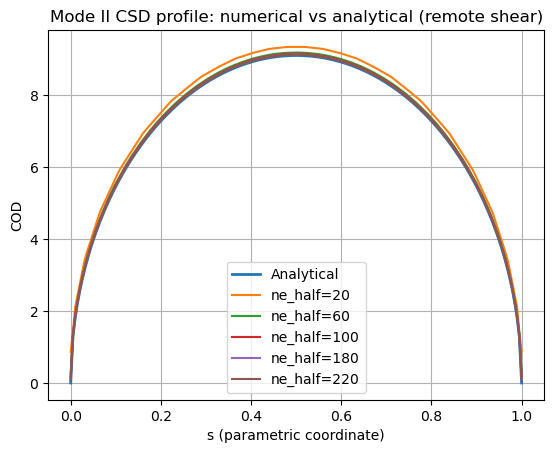

Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\CSD_validation_ModeII\csd_overlay_ne_half.png


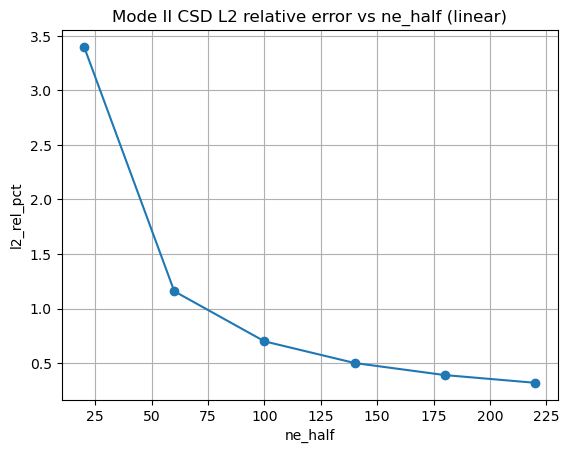

Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\CSD_validation_ModeII\csd_l2_error_vs_ne_half_linear.png


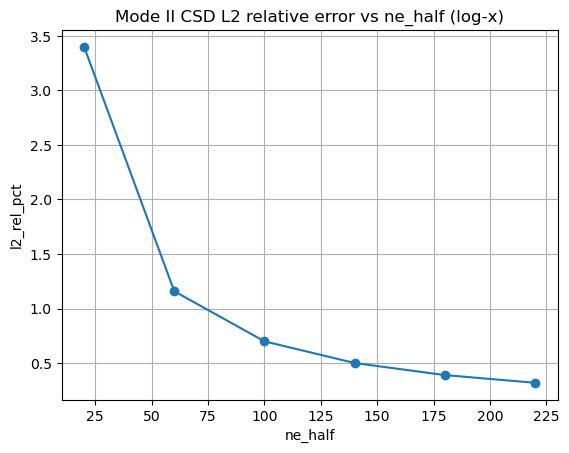

Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\CSD_validation_ModeII\csd_l2_error_vs_ne_half_logx.png


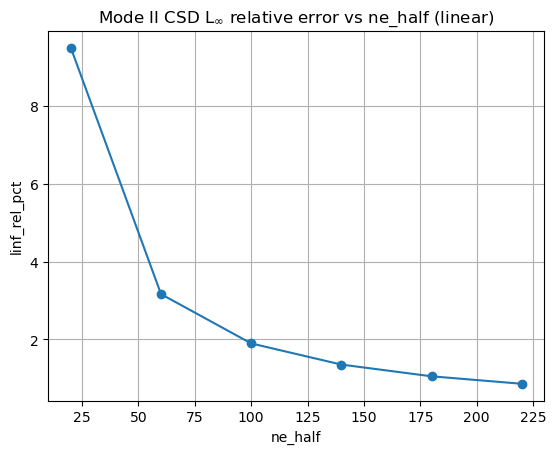

Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\CSD_validation_ModeII\csd_linf_error_vs_ne_half_linear.png


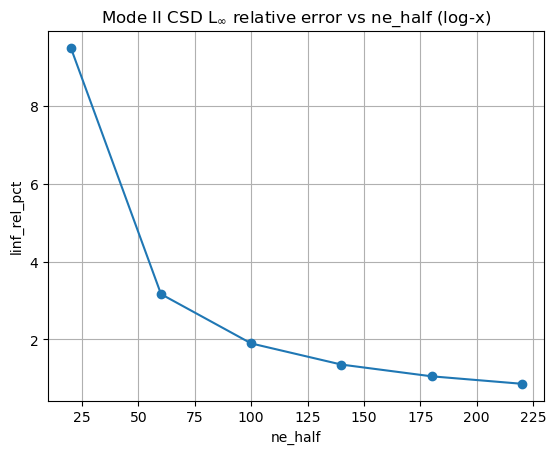

Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\CSD_validation_ModeII\csd_linf_error_vs_ne_half_logx.png

All plots saved to: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\CSD_validation_ModeII


In [28]:
#### VALIDATION OF A MODE II CRACK UNDER SHEAR LOADING (CSD)

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

cwd = Path(os.getcwd()).resolve()

# Find the nearest parent that contains a "fracture_utils" folder
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "fracture_utils").is_dir():
        repo_root = p
        break

if repo_root is None:
    # Fallback: hardcode the path you already see in tracebacks
    repo_root = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo_root =", repo_root)
print("fracture_utils importable =", (repo_root / "fracture_utils").is_dir())

from fracture_utils.UValidation.validation_cod import (
    CODProfile,        # reuse container (we will store CSD in the 'cod' field)
    run_cod_sweep,
    plot_cod_overlay,
    plot_cod_error_vs_knob,
)

from preamble import *
enable_autoreload()

# -------------------------
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\CSD_validation_ModeII")
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Output directory exists: {out_dir.exists()}")
print(f"Output directory: {out_dir}")

# -------------------------
# Crack/physics metadata (benchmark)
# -------------------------
mm = 1e-3
a_geom = 5.0 * mm  # half-length (m)
tau0   = 100e6      # remote shear (Pa)

crack_meta = dict(
    a=a_geom,
    tau=tau0,         # remote shear magnitude (Pa)
    E=200e9,
    nu=0.30,
    plane="strain",   # "strain" or "stress"
    edge_index=0,
)

# -------------------------
# Geometry: single horizontal crack (-a,0) -> (+a,0)
# Mode II: apply uniform remote shear sigma_xy = tau
# -------------------------
vertices = np.array([
    [0, -a_geom, 0.0],
    [1, +a_geom, 0.0],
], dtype=float)

connectivity = np.array([[0, 1]], dtype=int)

network = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(
    E=crack_meta["E"],
    nu=crack_meta["nu"],
    plane_stress=("stress" in crack_meta["plane"].lower()),
)

applied = AppliedStress(
    sigma_xx=0.0,
    sigma_yy=0.0,
    sigma_xy=+crack_meta["tau"],
)

calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

# -------------------------
# Solver hook: return CSD profile using the CODProfile container
# -------------------------
def run_solver_csd(knobs, crack_meta):
    """
    Returns CODProfile(s, csd_um) for one edge.
    We store CSD (sliding displacement jump) in the 'cod' field for reuse of plotting utilities.
    """
    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    edge_index = int(crack_meta.get("edge_index", 0))
    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    x   = np.asarray(x, float).reshape(-1)
    CSD = np.asarray(CSD, float).reshape(-1) * 1e6  # meters -> microns
    extra = dict(extra) if isinstance(extra, dict) else {}

    a_edge = float(extra.get("a_edge", np.max(np.abs(x))))
    s = (x + a_edge) / (2.0 * a_edge)  # map x in [-a_edge, a_edge] -> s in [0,1]

    return CODProfile(
        s=s,
        cod=CSD,  # store CSD in microns
        meta=dict(x=x, **extra),
    )

# -------------------------
# Analytical CSD (Mode II) for infinite plate, central crack under remote shear tau
# delta_t(x) = (4*tau/E') * sqrt(a^2 - x^2)
# Returns CSD in MICRONS.
# -------------------------
def analytical_csd(s, crack_meta):
    a   = float(crack_meta["a"])
    tau = float(crack_meta["tau"])
    E   = float(crack_meta["E"])
    nu  = float(crack_meta["nu"])
    plane = str(crack_meta.get("plane", "strain")).lower()
    Eprime = E / (1.0 - nu**2) if "strain" in plane else E

    s = np.asarray(s, float)
    x = (2.0 * s - 1.0) * a
    csd_m = (4.0 * tau / Eprime) * np.sqrt(np.maximum(a*a - x*x, 0.0))
    return csd_m * 1e6  # meters -> microns

# -------------------------
# Knob sweep
# -------------------------
ne_half_list = list(range(20, 260, 40))

knob_sweep = []
for ne in ne_half_list:
    knob_sweep.append(dict(
        ne_half=int(ne),
        crack_mode="full",              # set "half" if validating half-crack formulation
        representation="cheb_quad",     # "panel", "singular", "cheb_quad", "cheb_spectral"
        node_distribution="tip_dense",
        nq_col=12,
        nq_stress=16,
        ridge=1e-10,
        r0_factor=1e-3,
        solver_option="parametrized_crack",
        parametrization="polyline",
    ))

# -------------------------
# Run sweep
# -------------------------
sweep = run_cod_sweep(
    crack_meta=crack_meta,
    knob_sweep=knob_sweep,
    run_solver=run_solver_csd,
    analytical_cod=analytical_csd,   # reuse API; returns CSD
    s_sample=201,
)

# -------------------------
# Plot and save all figures
# -------------------------

# Figure 1: CSD overlay
result1 = plot_cod_overlay(
    sweep,
    knob_label_keys=("ne_half",),
    max_curves=5,
    title="Mode II CSD profile: numerical vs analytical (remote shear)",
)
if result1 is not None:
    fig1, ax1 = result1
    filepath1 = out_dir / "csd_overlay_ne_half.png"
    ax1.set_ylabel(r"CSD ($\mu$m)")
    ax1.set_xlabel("Normalized position s")
    ax1.grid(True)
    ax1.legend()
    fig1.savefig(filepath1, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath1}")
    plt.close(fig1)

# Figure 2: L2 error vs ne_half (linear)
result2 = plot_cod_error_vs_knob(
    sweep,
    knob="ne_half",
    metric="l2_rel_pct",
    title="Mode II CSD L2 relative error vs ne_half (linear)",
)
if result2 is not None:
    fig2, ax2 = result2
    filepath2 = out_dir / "csd_l2_error_vs_ne_half_linear.png"
    ax2.set_ylabel(r"Relative $L_2$ Error (%)")
    fig2.savefig(filepath2, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath2}")
    plt.close(fig2)

# Figure 3: L2 error vs ne_half (log-x)
result3 = plot_cod_error_vs_knob(
    sweep,
    knob="ne_half",
    metric="l2_rel_pct",
    title="Mode II CSD L2 relative error vs ne_half (log-x)",
)
if result3 is not None:
    fig3, ax3 = result3
    filepath3 = out_dir / "csd_l2_error_vs_ne_half_logx.png"
    ax3.set_xscale('log')
    ax3.set_ylabel(r"Relative $L_2$ Error (%)")
    ax3.grid(True, which='both')
    fig3.savefig(filepath3, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath3}")
    plt.close(fig3)

# Figure 4: Linf error vs ne_half (linear)
result4 = plot_cod_error_vs_knob(
    sweep,
    knob="ne_half",
    metric="linf_rel_pct",
    title=r"Mode II CSD $L_\infty$ relative error vs ne_half (linear)",
)
if result4 is not None:
    fig4, ax4 = result4
    filepath4 = out_dir / "csd_linf_error_vs_ne_half_linear.png"
    ax4.set_ylabel(r"Relative $L_\infty$ Error (%)")
    fig4.savefig(filepath4, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath4}")
    plt.close(fig4)

# Figure 5: Linf error vs ne_half (log-x)
result5 = plot_cod_error_vs_knob(
    sweep,
    knob="ne_half",
    metric="linf_rel_pct",
    title=r"Mode II CSD $L_\infty$ relative error vs ne_half (log-x)",
)
if result5 is not None:
    fig5, ax5 = result5
    filepath5 = out_dir / "csd_linf_error_vs_ne_half_logx.png"
    ax5.set_xscale('log')
    ax5.set_ylabel(r"Relative $L_\infty$ Error (%)")
    ax5.grid(True, which='both')
    fig5.savefig(filepath5, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath5}")
    plt.close(fig5)

print(f"\nAll plots saved to: {out_dir}")


Using repo_root = C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3
fracture_utils importable = True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Output directory exists: True
Output directory: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\CSD_validation_ModeII


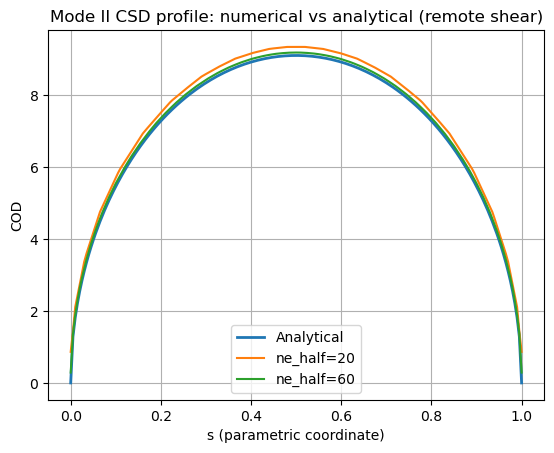

Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\CSD_validation_ModeII\csd_overlay_ne_half.png
Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\CSD_validation_ModeII\csd_combined_errors_vs_ne_half.png

All plots saved to: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\CSD_validation_ModeII


In [34]:
#### VALIDATION OF A MODE II CRACK UNDER SHEAR LOADING (CSD)

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

cwd = Path(os.getcwd()).resolve()

# Find the nearest parent that contains a "fracture_utils" folder
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "fracture_utils").is_dir():
        repo_root = p
        break

if repo_root is None:
    # Fallback: hardcode the path you already see in tracebacks
    repo_root = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo_root =", repo_root)
print("fracture_utils importable =", (repo_root / "fracture_utils").is_dir())

from fracture_utils.UValidation.validation_cod import (
    CODProfile,        # reuse container (we will store CSD in the 'cod' field)
    run_cod_sweep,
    plot_cod_overlay,
    plot_cod_error_vs_knob,
)

from preamble import *
enable_autoreload()

# -------------------------
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\CSD_validation_ModeII")
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Output directory exists: {out_dir.exists()}")
print(f"Output directory: {out_dir}")

# -------------------------
# Crack/physics metadata (benchmark)
# -------------------------
mm = 1e-3
a_geom = 5.0 * mm  # half-length (m)
tau0   = 100e6      # remote shear (Pa)

crack_meta = dict(
    a=a_geom,
    tau=tau0,         # remote shear magnitude (Pa)
    E=200e9,
    nu=0.30,
    plane="strain",   # "strain" or "stress"
    edge_index=0,
)

# -------------------------
# Geometry: single horizontal crack (-a,0) -> (+a,0)
# Mode II: apply uniform remote shear sigma_xy = tau
# -------------------------
vertices = np.array([
    [0, -a_geom, 0.0],
    [1, +a_geom, 0.0],
], dtype=float)

connectivity = np.array([[0, 1]], dtype=int)

network = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(
    E=crack_meta["E"],
    nu=crack_meta["nu"],
    plane_stress=("stress" in crack_meta["plane"].lower()),
)

applied = AppliedStress(
    sigma_xx=0.0,
    sigma_yy=0.0,
    sigma_xy=+crack_meta["tau"],
)

calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

# -------------------------
# Solver hook: return CSD profile using the CODProfile container
# -------------------------
def run_solver_csd(knobs, crack_meta):
    """
    Returns CODProfile(s, csd_um) for one edge.
    We store CSD (sliding displacement jump) in the 'cod' field for reuse of plotting utilities.
    """
    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    edge_index = int(crack_meta.get("edge_index", 0))
    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    x   = np.asarray(x, float).reshape(-1)
    CSD = np.asarray(CSD, float).reshape(-1) * 1e6  # meters -> microns
    extra = dict(extra) if isinstance(extra, dict) else {}

    a_edge = float(extra.get("a_edge", np.max(np.abs(x))))
    s = (x + a_edge) / (2.0 * a_edge)  # map x in [-a_edge, a_edge] -> s in [0,1]

    return CODProfile(
        s=s,
        cod=CSD,  # store CSD in microns
        meta=dict(x=x, **extra),
    )

# -------------------------
# Analytical CSD (Mode II) for infinite plate, central crack under remote shear tau
# delta_t(x) = (4*tau/E') * sqrt(a^2 - x^2)
# Returns CSD in MICRONS.
# -------------------------
def analytical_csd(s, crack_meta):
    a   = float(crack_meta["a"])
    tau = float(crack_meta["tau"])
    E   = float(crack_meta["E"])
    nu  = float(crack_meta["nu"])
    plane = str(crack_meta.get("plane", "strain")).lower()
    Eprime = E / (1.0 - nu**2) if "strain" in plane else E

    s = np.asarray(s, float)
    x = (2.0 * s - 1.0) * a
    csd_m = (4.0 * tau / Eprime) * np.sqrt(np.maximum(a*a - x*x, 0.0))
    return csd_m * 1e6  # meters -> microns

# -------------------------
# Knob sweep
# -------------------------
ne_half_list = list(range(20, 70, 40))

knob_sweep = []
for ne in ne_half_list:
    knob_sweep.append(dict(
        ne_half=int(ne),
        crack_mode="full",              # set "half" if validating half-crack formulation
        representation="cheb_quad",     # "panel", "singular", "cheb_quad", "cheb_spectral"
        node_distribution="tip_dense",
        nq_col=12,
        nq_stress=16,
        ridge=1e-10,
        r0_factor=1e-3,
        solver_option="parametrized_crack",
        parametrization="polyline",
    ))

# -------------------------
# Run sweep
# -------------------------
sweep = run_cod_sweep(
    crack_meta=crack_meta,
    knob_sweep=knob_sweep,
    run_solver=run_solver_csd,
    analytical_cod=analytical_csd,   # reuse API; returns CSD
    s_sample=201,
)

# -------------------------
# Plot and save figures
# -------------------------

# Figure 1: CSD overlay
result1 = plot_cod_overlay(
    sweep,
    knob_label_keys=("ne_half",),
    max_curves=5,
    title="Mode II CSD profile: numerical vs analytical (remote shear)",
)
if result1 is not None:
    fig1, ax1 = result1
    filepath1 = out_dir / "csd_overlay_ne_half.png"
    ax1.set_ylabel(r"CSD ($\mu$m)")
    ax1.set_xlabel("Normalized position s")
    ax1.grid(True)
    ax1.legend()
    fig1.savefig(filepath1, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath1}")
    plt.close(fig1)

# Figure 2: Combined L2 and Linf errors on same plot
fig2, ax2 = plt.subplots(figsize=(8, 6))

# Extract error data from sweep.results
ne_values = []
l2_errors = []
linf_errors = []

for item in sweep.results:  # Access .results attribute
    ne_values.append(item.knobs['ne_half'])  # item.knobs is a dict
    l2_errors.append(item.l2_rel_pct)        # Use attribute access
    linf_errors.append(item.linf_rel_pct)    # Use attribute access

# Plot both error metrics
ax2.plot(ne_values, l2_errors, marker='o', label=r'$L_2$ Error', linewidth=2)
ax2.plot(ne_values, linf_errors, marker='s', label=r'$L_\infty$ Error', linewidth=2)

ax2.set_xlabel('ne_half', fontsize=12)
ax2.set_ylabel('Relative Error (%)', fontsize=12)
ax2.set_title('Mode II CSD Convergence: Error vs Discretization', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

filepath2 = out_dir / "csd_combined_errors_vs_ne_half.png"
fig2.savefig(filepath2, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath2}")
plt.close(fig2)

print(f"\nAll plots saved to: {out_dir}")

In [ ]:
# --- SIF Validation Cell (4 estimators; PK uses window_frac + normal_offset_frac sweep) ---
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Ensure repo root on sys.path (robust)
# -------------------------
cwd = Path(os.getcwd()).resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "fracture_utils").is_dir():
        repo_root = p
        break
if repo_root is None:
    repo_root = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo_root =", repo_root)
print("fracture_utils importable =", (repo_root / "fracture_utils").is_dir())

from preamble import *
enable_autoreload()

# -------------------------
# Imports: updated results + updated PK + SIF utilities
# -------------------------
from fracture_utils.Uprocessor.results_v1_PATHIND_updated import DCEResultsNetworkV4
from fracture_utils.Uprocessor.PK_PATHIND_updated_v2 import PKProcessor

from fracture_utils.Uprocessor.SIF import (
    sif_from_cod_fit,
    estimate_KI_KII_from_jumps_near_tip,
)

# -------------------------
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\SIF_validation")
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Benchmark: straight crack, Mode I
# -------------------------
mm = 1e-3
a_geom = 5.0 * mm
sigma0 = 100e6

crack_meta = dict(
    a=a_geom,
    sigma=sigma0,
    E=200e9,
    nu=0.30,
    plane="strain",  # "strain" or "stress"
    edge_index=0,
)

# -------------------------
# Build a single-edge network
# -------------------------
vertices = np.array([
    [0, -a_geom, 0.0],
    [1, +a_geom, 0.0],
], dtype=float)

connectivity = np.array([[0, 1]], dtype=int)

network = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

plane_stress = ("stress" in str(crack_meta["plane"]).lower())
material = Material(E=crack_meta["E"], nu=crack_meta["nu"], plane_stress=plane_stress)
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=+crack_meta["sigma"], sigma_xy=0.0)
calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

# -------------------------
# Analytical SIF
# -------------------------
def KI_analytic(a, sigma):
    return float(sigma * np.sqrt(np.pi * a))

# -------------------------
# Run one solve and return the 3 "good" estimators + PK (with tunables)
# -------------------------
def solve_and_estimate(ne_half: int, *, window_frac: float, normal_offset_frac: float, representation: str = "cheb_quad"):
    knobs = dict(
        ne_half=int(ne_half),
        crack_mode="half",
        representation=str(representation),
        node_distribution="tip_dense",
        nq_col=12,
        nq_stress=16,
        ridge=1e-10,
        r0_factor=1e-3,
        solver_option="parametrized_crack",
        parametrization="polyline",
    )
    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    edge_index = int(crack_meta.get("edge_index", 0))

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(edge_index=edge_index, enforce_global_tip_zero=True)
    extra = dict(extra) if isinstance(extra, dict) else {}
    a_fit = float(extra.get("a_edge", float(crack_meta["a"])))

    E  = float(res.calc.material.E)
    nu = float(res.calc.material.nu)
    mu = E / (2.0 * (1.0 + nu))
    plane_stress_local = bool(getattr(res.calc.material, "plane_stress", False))
    kappa  = (3.0 - nu) / (1.0 + nu) if plane_stress_local else (3.0 - 4.0 * nu)
    Eprime = E if plane_stress_local else (E / (1.0 - nu**2))

    # Tip-fit
    KI_tip, KII_tip, _ = sif_from_cod_fit(
        x=x, COD=COD, CSD=CSD,
        a=a_fit, mu=mu, kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=1e-6,
        rho_max=0.80,
        min_pts=10,
        n_fit=400,
        two_term=True,
    )

    # Jump
    KI_jump, KII_jump = estimate_KI_KII_from_jumps_near_tip(
        x=x, COD=COD, CSD=CSD,
        a=a_fit,
        Eprime=Eprime,
        side="right",
        frac_window=0.08,
    )

    # PK (Mode I: KI = sqrt(E' * J1))
    pk = PKProcessor(res)
    F = pk.F_PK_window(
        edge_index=edge_index,
        at="end",
        exclude_self=True,
        window_panels=0,               # force frac-mode
        window_frac=float(window_frac),
        min_panels=12,
        normal_offset_frac=float(normal_offset_frac),
    )
    if F is None:
        KI_pk = float("nan")
        J1 = float("nan")
    else:
        # local tangent from reconstructor
        _, _, _, extra2 = res.reconstruct_cod_csd_panel_midpoints(edge_index=edge_index, enforce_global_tip_zero=False)
        extra2 = dict(extra2)
        ex = np.asarray(extra2["ex"], float).reshape(2,)
        J1 = float(np.dot(np.asarray(F, float).reshape(2,), ex))
        KI_pk = float(np.sqrt(max(E * J1, 0.0)))

    # Mode I analytic
    KI_ref = KI_analytic(a_fit, float(crack_meta["sigma"]))

    return dict(
        ne_half=int(ne_half),
        a_fit=a_fit,
        Eprime=Eprime,
        KI_ref=KI_ref,
        KI_tip=float(KI_tip),
        KI_jump=float(KI_jump),
        KI_pk=float(KI_pk),
        J1=float(J1),
    )

# -------------------------
# Sweep ne_half with a small grid of PK tunables and plot
# -------------------------
ne_half_list = list(range(20, 420, 40))

# Choose a few combinations (3–5) to avoid crowding
pk_variants = [
    # dict(window_frac=0.20, normal_offset_frac=0.0,    label="wf=0.20, off=0"),
    dict(window_frac=0.50, normal_offset_frac=5e-6, label="wf=0.50"),
]

# Precompute baseline tip/jump once per ne_half (reuse first variant result)
baseline = {}
pk_results = {v["label"]: [] for v in pk_variants}

for ne in ne_half_list:
    r0 = solve_and_estimate(ne, window_frac=pk_variants[0]["window_frac"], normal_offset_frac=pk_variants[0]["normal_offset_frac"])
    baseline[ne] = dict(KI_ref=r0["KI_ref"], KI_tip=r0["KI_tip"], KI_jump=r0["KI_jump"])

    for v in pk_variants:
        r = solve_and_estimate(ne, window_frac=v["window_frac"], normal_offset_frac=v["normal_offset_frac"])
        pk_results[v["label"]].append(r)

# -------------------------
# Plot error vs ne_half
# -------------------------
def err_pct(K, Kref):
    return 100.0 * (K - Kref) / Kref

# First figure: linear x-axis
fig1, ax1 = plt.subplots()
ax1.plot(ne_half_list, [err_pct(baseline[ne]["KI_tip"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_tip")
ax1.plot(ne_half_list, [err_pct(baseline[ne]["KI_jump"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_jump")
# PK variants
for lab, arr in pk_results.items():
    ax1.plot(ne_half_list, [err_pct(a["KI_pk"], a["KI_ref"]) for a in arr], marker="o", label=f"K_pk ({lab})")
ax1.set_xlabel("ne_half")
ax1.set_ylabel("Error (%)")
ax1.set_title("Mode I SIF error vs ne_half (linear)")
ax1.grid(True)
ax1.legend()
filepath1 = out_dir / 'sif_error_vs_ne_half_ncol12_nsig16_linear.png'
fig1.savefig(filepath1, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath1}")

# Second figure: log x-axis
fig2, ax2 = plt.subplots()
ax2.plot(ne_half_list, [err_pct(baseline[ne]["KI_tip"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_tip")
ax2.plot(ne_half_list, [err_pct(baseline[ne]["KI_jump"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_jump")
# PK variants
for lab, arr in pk_results.items():
    ax2.plot(ne_half_list, [err_pct(a["KI_pk"], a["KI_ref"]) for a in arr], marker="o", label=f"K_pk ({lab})")
ax2.set_xlabel("ne_half")
ax2.set_ylabel("Error (%)")
ax2.set_title("Mode I SIF error vs ne_half (log scale)")
ax2.set_xscale('log')
ax2.grid(True, which='both')
ax2.legend()
filepath2 = out_dir / 'sif_error_vs_ne_half_ncol12_nsig16_log.png'
fig2.savefig(filepath2, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath2}")

plt.show()


Using repo_root = C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3
fracture_utils importable = True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

Output directory exists: True
Output directory: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\SIF_validation
Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\SIF_validation\sif_error_vs_ne_half_ncol12_nsig16_linear.png
Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\SIF_validation\sif_error_vs_ne_half_ncol12_nsig16_log.png


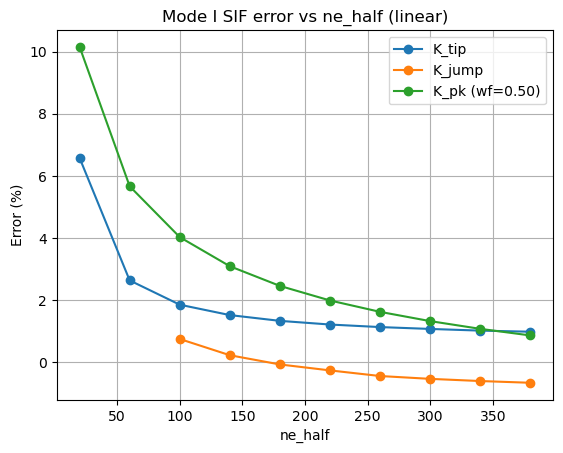

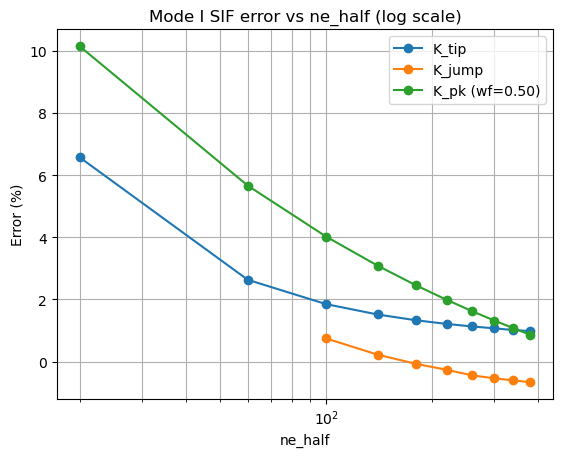

In [20]:
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\SIF_validation")
out_dir.mkdir(parents=True, exist_ok=True)

# Verify directory was created
print(f"Output directory exists: {out_dir.exists()}")
print(f"Output directory: {out_dir}")

# First figure: linear x-axis
fig1, ax1 = plt.subplots()
ax1.plot(ne_half_list, [err_pct(baseline[ne]["KI_tip"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_tip")
ax1.plot(ne_half_list, [err_pct(baseline[ne]["KI_jump"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_jump")
# PK variants
for lab, arr in pk_results.items():
    ax1.plot(ne_half_list, [err_pct(a["KI_pk"], a["KI_ref"]) for a in arr], marker="o", label=f"K_pk ({lab})")
ax1.set_xlabel("ne_half")
ax1.set_ylabel("Error (%)")
ax1.set_title("Mode I SIF error vs ne_half (linear)")
ax1.grid(True)
ax1.legend()
filepath1 = out_dir / 'sif_error_vs_ne_half_ncol12_nsig16_linear.png'
fig1.savefig(filepath1, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath1}")

# Second figure: log x-axis
fig2, ax2 = plt.subplots()
ax2.plot(ne_half_list, [err_pct(baseline[ne]["KI_tip"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_tip")
ax2.plot(ne_half_list, [err_pct(baseline[ne]["KI_jump"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_jump")
# PK variants
for lab, arr in pk_results.items():
    ax2.plot(ne_half_list, [err_pct(a["KI_pk"], a["KI_ref"]) for a in arr], marker="o", label=f"K_pk ({lab})")
ax2.set_xlabel("ne_half")
ax2.set_ylabel("Error (%)")
ax2.set_title("Mode I SIF error vs ne_half (log scale)")
ax2.set_xscale('log')
ax2.grid(True, which='both')
ax2.legend()
filepath2 = out_dir / 'sif_error_vs_ne_half_ncol12_nsig16_log.png'
fig2.savefig(filepath2, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath2}")

# Show AFTER all saves (optional - only if you want to see them)
plt.show()

# OR skip show and just close to save memory:
# plt.close(fig1)
# plt.close(fig2)

Using repo_root = C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3
fracture_utils importable = True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

Solving ne_half = 20

Solving ne_half = 40

Solving ne_half = 60


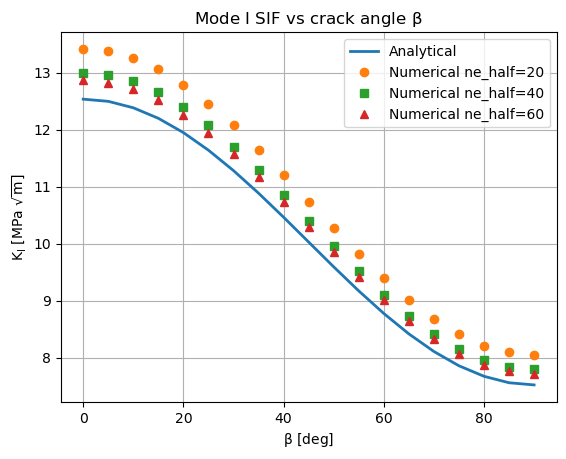

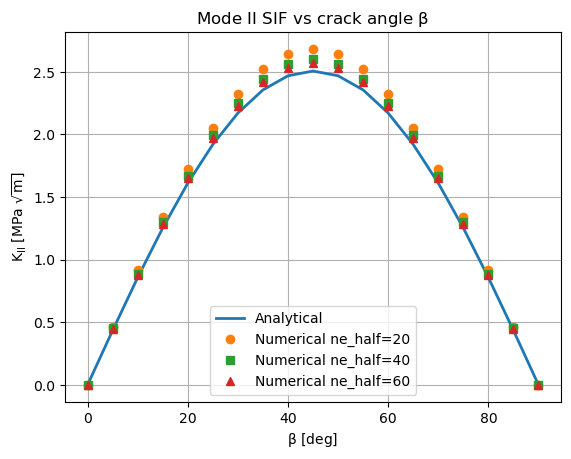


Saved plots to: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\MixedMode_SIF_validation


In [ ]:
# --- Mixed-Mode SIF validation: inclined crack under biaxial loading (plots like Fig. B/C) ---
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Ensure repo root on sys.path (robust)
# -------------------------
cwd = Path(os.getcwd()).resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "fracture_utils").is_dir():
        repo_root = p
        break
if repo_root is None:
    repo_root = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo_root =", repo_root)
print("fracture_utils importable =", (repo_root / "fracture_utils").is_dir())

from preamble import *
enable_autoreload()

from fracture_utils.Uprocessor.results_v1_PATHIND_updated import DCEResultsNetworkV4
from fracture_utils.Uprocessor.SIF import sif_from_cod_fit

# -------------------------
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\MixedMode_SIF_validation")
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Problem definition (match the paper figure)
# Crack length = 2a, inclined by beta from loading axis.
# Analytical (Rooke & Cartwright):
#   KI  = sqrt(pi a) ( σ22 cos^2β + σ11 sin^2β )
#   KII = sqrt(pi a) ( σ22 - σ11 ) sinβ cosβ
# -------------------------
mm = 1e-3
a = 5.0 * mm                  # half-length (m)
sig11 = 60e6                  # Pa  (σ11)
sig22 = 100e6                 # Pa  (σ22)
plane = "strain"              # "strain" or "stress"
edge_index = 0

# Sweep β in degrees (0..90)
beta_deg = np.linspace(0.0, 90.0, 19)
beta_rad = np.deg2rad(beta_deg)

# Numerical resolutions
ne_list = [20, 40, 60, 120]

# Solver knobs (common)
base_knobs = dict(
    crack_mode="full",
    representation="cheb_quad",     # you can switch to "cheb_spectral" once stable
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    parametrization="polyline",
)

# -------------------------
# Helpers
# -------------------------
def analytical_K(beta):
    """Return (KI, KII) for beta (radians)."""
    KI  = np.sqrt(np.pi * a) * (sig22 * (np.cos(beta)**2) + sig11 * (np.sin(beta)**2))
    KII = np.sqrt(np.pi * a) * ((sig22 - sig11) * np.sin(beta) * np.cos(beta))
    return KI, KII

def crack_endpoints(beta):
    """Horizontal crack rotated by beta about origin."""
    c = np.cos(beta); s = np.sin(beta)
    p0 = np.array([-a, 0.0])
    p1 = np.array([+a, 0.0])
    R = np.array([[c, -s],[s, c]])
    q0 = R @ p0
    q1 = R @ p1
    return q0, q1

def solve_K_for_beta(beta, ne_half):
    """Solve for a given beta and ne_half; return (KI_tip, KII_tip)."""
    q0, q1 = crack_endpoints(beta)

    vertices = np.array([
        [0, q0[0], q0[1]],
        [1, q1[0], q1[1]],
    ], dtype=float)

    connectivity = np.array([[0, 1]], dtype=int)

    network = CrackNetworkV4.from_vertices_connectivity(
        vertices=vertices,
        connectivity=connectivity,
        Nv_max=3,
        validate=True,
    )

    material = Material(
        E=200e9,
        nu=0.30,
        plane_stress=("stress" in plane.lower()),
    )

    applied = AppliedStress(
        sigma_xx=float(sig11),
        sigma_yy=float(sig22),
        sigma_xy=0.0,
    )

    calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

    knobs = dict(base_knobs)
    knobs["ne_half"] = int(ne_half)

    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )
    extra = dict(extra) if isinstance(extra, dict) else {}
    a_fit = float(extra.get("a_edge", a))

    # elastic constants for sif_from_cod_fit
    E  = float(res.calc.material.E)
    nu = float(res.calc.material.nu)
    mu = E / (2.0 * (1.0 + nu))
    plane_stress_local = bool(getattr(res.calc.material, "plane_stress", False))
    kappa = (3.0 - nu) / (1.0 + nu) if plane_stress_local else (3.0 - 4.0 * nu)

    KI, KII, meta = sif_from_cod_fit(
        x=x, COD=COD, CSD=CSD,
        a=a_fit,
        mu=mu,
        kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=1e-6,
        rho_max=0.60,
        min_pts=10,
        n_fit=400,
        two_term=True,
    )
    return float(KI), float(KII)

# -------------------------
# Compute curves
# -------------------------
KI_ana = np.zeros_like(beta_deg, float)
KII_ana = np.zeros_like(beta_deg, float)
for i, b in enumerate(beta_rad):
    KI_ana[i], KII_ana[i] = analytical_K(b)

KI_num = {ne: np.zeros_like(beta_deg, float) for ne in ne_list}
KII_num = {ne: np.zeros_like(beta_deg, float) for ne in ne_list}

for ne in ne_list:
    print(f"\nSolving ne_half = {ne}")
    for i, b in enumerate(beta_rad):
        KI, KII = solve_K_for_beta(b, ne_half=ne)
        KI_num[ne][i] = KI
        KII_num[ne][i] = KII

# Convert to MPa*sqrt(m) for plotting
scale = 1e-6  # Pa*sqrt(m) -> MPa*sqrt(m)
KI_ana_p = KI_ana * scale
KII_ana_p = KII_ana * scale
KI_num_p = {ne: KI_num[ne] * scale for ne in ne_list}
KII_num_p = {ne: KII_num[ne] * scale for ne in ne_list}

# -------------------------
# Plot (B): KI vs beta
# -------------------------
figB, axB = plt.subplots()
axB.plot(beta_deg, KI_ana_p, label="Analytical", linewidth=2)
markers = {20:"o", 40:"s", 60:"^"}
for ne in ne_list:
    axB.plot(beta_deg, KI_num_p[ne], marker=markers.get(ne,"o"), linestyle="None", label=f"Numerical ne_half={ne}")
axB.set_xlabel(r"$\beta$ [deg]")
axB.set_ylabel(r"$K_I$ [MPa $\sqrt{m}$]")
axB.set_title(r"Mode I SIF vs crack angle $\beta$")
axB.grid(True)
axB.legend()
figB.savefig(out_dir / "KI_vs_beta.png", dpi=300, bbox_inches="tight")
plt.show()

# -------------------------
# Plot (C): KII vs beta
# -------------------------
figC, axC = plt.subplots()
axC.plot(beta_deg, KII_ana_p, label="Analytical", linewidth=2)
for ne in ne_list:
    axC.plot(beta_deg, KII_num_p[ne], marker=markers.get(ne,"o"), linestyle="None", label=f"Numerical ne_half={ne}")
axC.set_xlabel(r"$\beta$ [deg]")
axC.set_ylabel(r"$K_{II}$ [MPa $\sqrt{m}$]")
axC.set_title(r"Mode II SIF vs crack angle $\beta$")
axC.grid(True)
axC.legend()
figC.savefig(out_dir / "KII_vs_beta.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved plots to: {out_dir}")


In [ ]:
# ============================================================
# Mixed-Mode SIF validation: KI(β), KII(β) + error convergence
# ============================================================

import os, sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Repo root discovery
# ------------------------------------------------------------
cwd = Path(os.getcwd()).resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "fracture_utils").is_dir():
        repo_root = p
        break
if repo_root is None:
    repo_root = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3")
sys.path.insert(0, str(repo_root))

from preamble import *
enable_autoreload()

from fracture_utils.Uprocessor.SIF import sif_from_cod_fit
from fracture_utils.Uprocessor.results_v1 import DCEResultsNetworkV4


# -------------------------
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\MixedMode_SIF_validation")
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Problem definition (match the paper figure)
# Crack length = 2a, inclined by beta from loading axis.
# Analytical (Rooke & Cartwright):
#   KI  = sqrt(pi a) ( σ22 cos^2β + σ11 sin^2β )
#   KII = sqrt(pi a) ( σ22 - σ11 ) sinβ cosβ
# -------------------------

# ------------------------------------------------------------
# Geometry & material
# ------------------------------------------------------------
mm = 1e-3
a = 5.0 * mm
E = 200e9
nu = 0.30
plane_strain = True
mu = E / (2.0 * (1.0 + nu))
kappa = 3.0 - 4.0 * nu if plane_strain else (3.0 - nu) / (1.0 + nu)

sigma_11 = 60e6
sigma_22 = 100e6

# ------------------------------------------------------------
# Analytical mixed-mode SIFs (Rooke–Cartwright)
# ------------------------------------------------------------
def analytical_K(beta):
    beta = np.asarray(beta)
    KI  = np.sqrt(np.pi * a) * (sigma_22 * np.cos(beta)**2 + sigma_11 * np.sin(beta)**2)
    KII = np.sqrt(np.pi * a) * (sigma_22 - sigma_11) * np.sin(beta) * np.cos(beta)
    return KI, KII

# ------------------------------------------------------------
# Crack angles
# ------------------------------------------------------------
beta_deg = np.linspace(0.0, 90.0, 181)
beta = np.deg2rad(beta_deg)

KI_ana, KII_ana = analytical_K(beta)

# ------------------------------------------------------------
# Solver setup
# ------------------------------------------------------------
ne_list = [20, 40, 60, 120]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

KI_num = {}
KII_num = {}

for ne in ne_list:

    KI_vals = []
    KII_vals = []

    for b in beta:

        # rotate crack by β
        dx = a * np.cos(b)
        dy = a * np.sin(b)

        vertices = np.array([
            [0, -dx, -dy],
            [1,  dx,  dy],
        ], float)

        connectivity = np.array([[0, 1]], int)

        network = CrackNetworkV4.from_vertices_connectivity(
            vertices=vertices,
            connectivity=connectivity,
            Nv_max=3,
            validate=True,
        )

        material = Material(E=E, nu=nu, plane_stress=not plane_strain)
        applied  = AppliedStress(sigma_xx=sigma_11, sigma_yy=sigma_22, sigma_xy=0.0)

        calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

        sol = calc.solve(
            ne_half=ne,
            crack_mode="full",
            representation="cheb_quad",
            node_distribution="tip_dense",
            nq_col=10,
            nq_stress=16,
            ridge=1e-10,
            r0_factor=1e-3,
            solver_option="parametrized_crack",
            parametrization="polyline",
        )

        res = DCEResultsNetworkV4(calc, sol)

        x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
            edge_index=0,
            enforce_global_tip_zero=True,
        )

        a_fit = float(extra.get("a_edge", a))

        KI, KII, _ = sif_from_cod_fit(
            x=x, COD=COD, CSD=CSD,
            a=a_fit,
            mu=mu,
            kappa=kappa,
            tip="right",
            rho_min=1e-6,
            rho_max=0.5,
            min_pts=8,
            n_fit=200,
            two_term=True,
        )

        KI_vals.append(KI)
        KII_vals.append(KII)

    KI_num[ne] = np.array(KI_vals)
    KII_num[ne] = np.array(KII_vals)

# ------------------------------------------------------------
# Plot 1: KI vs β
# ------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(beta_deg, KI_ana, "k--", lw=3, label="Analytical")
for ne, c in zip(ne_list, colors):
    plt.plot(beta_deg, KI_num[ne], color=c, lw=2, label=f"ne_half={ne}")
plt.xlabel(r"$\beta$ (deg)")
plt.ylabel(r"$K_I$")
plt.title("Mode I SIF vs crack orientation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2: KII vs β
# ------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(beta_deg, KII_ana, "k--", lw=3, label="Analytical")
for ne, c in zip(ne_list, colors):
    plt.plot(beta_deg, KII_num[ne], color=c, lw=2, label=f"ne_half={ne}")
plt.xlabel(r"$\beta$ (deg)")
plt.ylabel(r"$K_{II}$")
plt.title("Mode II SIF vs crack orientation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Error norms vs ne_half
# ------------------------------------------------------------
def rel_L2(num, ana):
    return np.linalg.norm(num - ana) / np.linalg.norm(ana) * 100.0

def rel_Linf(num, ana):
    return np.max(np.abs(num - ana)) / np.max(np.abs(ana)) * 100.0

KI_L2   = [rel_L2(KI_num[ne],  KI_ana)  for ne in ne_list]
KI_Linf = [rel_Linf(KI_num[ne],KI_ana)  for ne in ne_list]
KII_L2  = [rel_L2(KII_num[ne], KII_ana) for ne in ne_list]
KII_Linf= [rel_Linf(KII_num[ne],KII_ana)for ne in ne_list]

fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].plot(ne_list, KI_L2,   "o-", label=r"$L_2$")
ax[0].plot(ne_list, KI_Linf, "s--", label=r"$L_\infty$")
ax[0].set_title(r"$K_I$ error")
ax[0].set_xlabel("ne_half")
ax[0].set_ylabel("Error (%)")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(ne_list, KII_L2,   "o-", label=r"$L_2$")
ax[1].plot(ne_list, KII_Linf, "s--", label=r"$L_\infty$")
ax[1].set_title(r"$K_{II}$ error")
ax[1].set_xlabel("ne_half")
ax[1].set_ylabel("Error (%)")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()
